<a href="https://colab.research.google.com/github/utkarshg1/DeepLearning-6th-July/blob/main/Restaurant_Reviews_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment analysis
 (also called opinion mining) is the process of using natural language processing (NLP) and machine learning to determine whether a piece of text expresses a positive, negative, or neutral emotion. It helps businesses and researchers understand customer opinions, brand reputation, and emotional tone in large volumes of text such as reviews, social media posts, and surveys.

Applications:

Customer feedback analysis

Brand reputation monitoring

Product development insights

Competitor comparison

Marketing campaign evaluation

#Recurrent Neural Networks (RNNs)
are a type of neural network designed to handle sequential data, such as time-series data and text data. Unlike traditional neural networks, RNNs have a unique architecture that allows them to maintain a hidden state, which acts as a memory of previous inputs. This hidden state enables RNNs to capture temporal dependencies and make predictions based on past information.


Training RNNs involves using a technique called Backpropagation Through Time (BPTT). This method involves unrolling the RNN over time and applying backpropagation to update the weights. The loss function is calculated based on the difference between the predicted output and the actual output, and the error is propagated back through the network to update the weights.

#Advantages:
RNNs can remember previous inputs, making them suitable for time-series prediction and other sequential data tasks.

#Disadvantages:
RNNs suffer from vanishing and exploding gradient problems, making training difficult.

# Sentiment Analysis with Keras

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')
# Download resources (run once)
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Download the punkt_tab resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

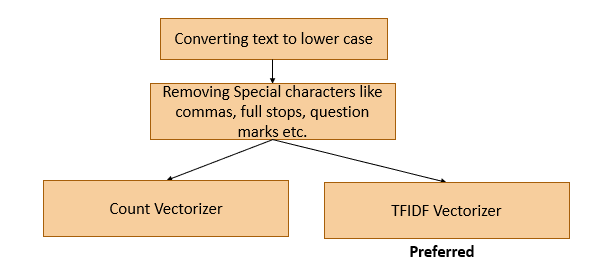

### Step 1: Read the dataset

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Restaurant_Reviews.csv')
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good. ## $%,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


### Create a function to preprocess text

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def preprocess_text(s):
  s = s.lower()
  # Remove non-alphabetic characters (covers most symbols, numbers, and punctuation)
  s=re.sub("[^a-z ]"," ",s)
  tokens = word_tokenize(s)
  stop_words = set(stopwords.words('english'))
  stop_words.discard("not")
  stop_words.discard("no")
  stop_words.discard("bad")
  stop_words.discard("never")
 # print(stop_words)

  filtered_tokens = [i for i in tokens if i not in stop_words]
  return " ".join(filtered_tokens)

### Apply preprocessing on dataframe

In [ ]:
df['clean_Review'] = df['Review'].apply(preprocess_text)

In [ ]:
df

,Review,Liked,clean_Review
0,Wow... Loved this place.,1,wow loved place
1,Crust is not good. ## $%,0,crust not good
2,Not tasty and the texture was just nasty.,0,not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great prices
...,...,...,...
995,I think food should have flavor and texture an...,0,think food flavor texture lacking
996,Appetite instantly gone.,0,appetite instantly gone
997,Overall I was not impressed and would not go b...,0,overall not impressed would not go back
998,"The whole experience was underwhelming, and I ...",0,whole experience underwhelming think go ninja ...


### Apply TFIDF Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_pre = tfidf.fit_transform(df['clean_Review']).toarray()

In [ ]:
X_pre.shape

(1000, 1888)

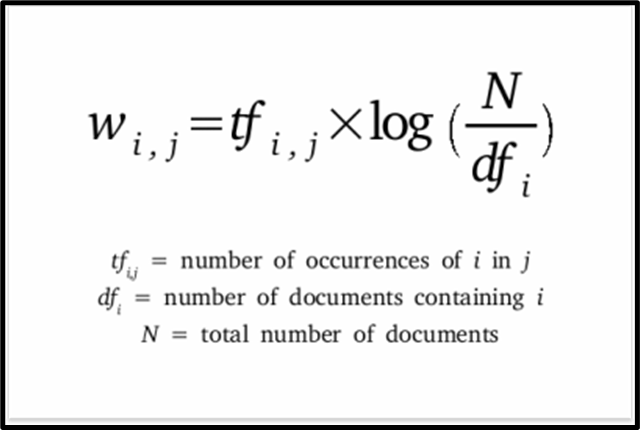

In [ ]:
Y = df['Liked']

### Apply Train test split

In [ ]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X_pre, Y, test_size=0.1, random_state=40)

In [ ]:
xtrain.shape[1]

1888

In [ ]:
xtest.shape

(100, 1888)

### Build The Neural Net

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()

# Input Layer
model.add(Input(shape=(xtrain.shape[1],)))
#xtrain.shape[1] represents the number of features in the training data xtrain. This determines the size of the input layer.
#Example: If xtrain has 100 features (columns), the input layer expects a vector of length 100.

# Hidden Layer 1
model.add(Dense(1000, activation='relu'))
# Dropout Layer 1
model.add(Dropout(0.2))
# Regularization technique to prevent overfitting.
#Dropout Layer: first dropout layer, 30% of neurons are ignored during training to enhance generalization.

# Hidden Layer 2
model.add(Dense(500, activation='relu'))
# Dropout layer 2
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))
#The final layer has 1 neuron because this is likely a binary classification task.
#Each input from the previous layer is connected to this single output neuron.
#Activation Function (sigmoid):
#Squashes the output to a value between 0 and 1, which is ideal for binary classification (e.g., predicting probabilities).

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#hist = model.fit(xtrain, ytrain,validation_split=0.1,batch_size=16,epochs=50)

In [ ]:
es = EarlyStopping(patience=10)
hist = model.fit(xtrain, ytrain,validation_split=0.1,batch_size=16,epochs=50,callbacks=[es])

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.5938 - loss: 0.6632 - val_accuracy: 0.7111 - val_loss: 0.5758
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9136 - loss: 0.2866 - val_accuracy: 0.8222 - val_loss: 0.4148
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9827 - loss: 0.0550 - val_accuracy: 0.7444 - val_loss: 0.5689
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9951 - loss: 0.0185 - val_accuracy: 0.7889 - val_loss: 0.5081
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9963 - loss: 0.0122 - val_accuracy: 0.7778 - val_loss: 0.5881
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.7889 - val_loss: 0.5771
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9951 - loss: 0.0120 - val_accuracy: 0.7889 - val_loss: 0.6098
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9963 - loss: 0.0095 - val_accuracy: 0.7667 - val_loss

#Use Case :
This model could be used for binary classification tasks such as spam detection, sentiment analysis, or fraud detection.

#Summary
Use the Adam optimizer to adjust weights.
Minimize the binary cross-entropy loss, which is well-suited for binary classification tasks.
Track accuracy as a measure of how well the model performs during training and evaluation.

In [ ]:
es = EarlyStopping(patience=20)

Early stopping is a technique to prevent overfitting during training by halting the process once the model stops improving on a validation dataset.
##patience=10:
Specifies how many epochs to wait for an improvement before stopping the training.

In [ ]:
hist = model.fit(xtrain, ytrain,
                 validation_split=0.2,
                 batch_size=16,
                 epochs=50,
                 callbacks=[es])

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5833 - loss: 0.6889 - val_accuracy: 0.6167 - val_loss: 0.6810
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8361 - loss: 0.6019 - val_accuracy: 0.7333 - val_loss: 0.5627
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9417 - loss: 0.2745 - val_accuracy: 0.7500 - val_loss: 0.4796
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9819 - loss: 0.0801 - val_accuracy: 0.7389 - val_loss: 0.5654
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0339 - val_accuracy: 0.7389 - val_loss: 0.5883
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0245 - val_accuracy: 0.7278 - val_loss: 0.7074
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0235 - val_accuracy: 0.7167 - val_loss: 0.8032
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9931 - loss: 0.0176 - val_accuracy: 0.7278 - val_loss

### Learning curve

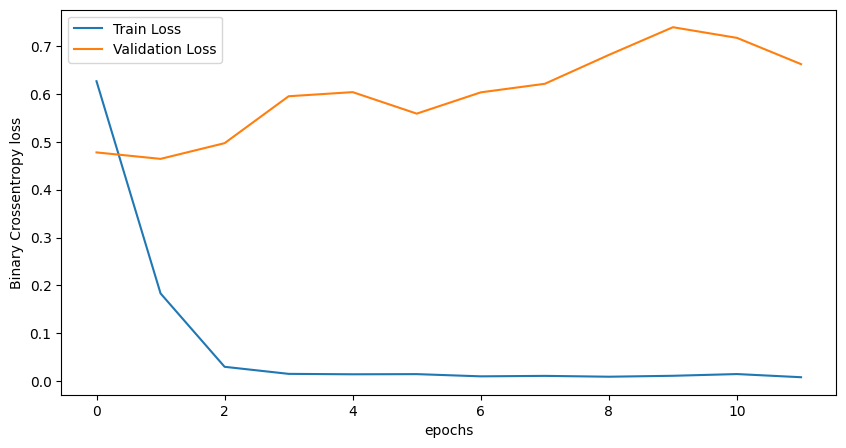

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.xlabel('epochs')
plt.ylabel('Binary Crossentropy loss')
plt.legend()
plt.show()

### Evaluate the model

In [ ]:
model.evaluate(xtrain, ytrain)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9778 - loss: 0.0706


[0.07062903791666031, 0.9777777791023254]

In [ ]:
model.evaluate(xtest, ytest)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7700 - loss: 0.6545 


[0.6545401811599731, 0.7699999809265137]

### Predict results for train and test

In [ ]:
yprob_train = model.predict(xtrain)
yprob_test = model.predict(xtest)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
ypred_train = [1 if prob>=0.5 else 0 for prob in yprob_train]
ypred_test = [1 if prob>=0.5 else 0 for prob in yprob_test]

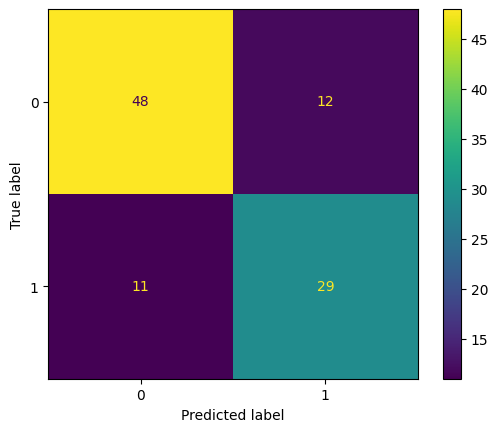

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(ytest, ypred_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred_test))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        60
           1       0.71      0.72      0.72        40

    accuracy                           0.77       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.77      0.77      0.77       100



### Save the model for future use

In [ ]:
model.save("SentimentModel.keras")

### Load the model

In [ ]:
from keras.models import load_model

In [ ]:
rnn = load_model("/content/SentimentModel.keras")

### Out of sample prediction

In [ ]:
def predict_sentiment():
  text = input("Please enter restuaraunt review : ")
  text = preprocess_text(text)
  text_pre = tfidf.transform([text]).toarray()
  prob = rnn.predict(text_pre)
  if prob>=0.5:
    print("Positive Review")
  else:
    print("Negative Review")
  return prob

In [ ]:
predict_sentiment()

Please enter restuaraunt review : Wow... Loved this place.	
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Positive Review


array([[0.9999628]], dtype=float32)

In [ ]:
predict_sentiment()

Please enter restuaraunt review : bad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Negative Review


array([[5.3712924e-06]], dtype=float32)